# **Customer Churn Prediction & Deployment Pipeline**

# Workflow (Step-by-Step Code Process):

Data Loading → Data Cleaning → Exploratory Data Analysis (EDA) → Feature Encoding & Scaling → Train-Test Split → Model Training & Selection → Model Evaluation → Deployment Preparation → New Customer Prediction

# Import Libraries

In [59]:
# !pip install xgboost

In [60]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Load Dataset

In [61]:
raw_data = pd.read_csv('customer_churn_dataset.csv')
data = raw_data.copy()

# Data Inspection and Cleaning

In [62]:
data.shape

(96096, 10)

In [63]:
data.columns

Index(['customer_unique_id', 'total_orders', 'total_spent', 'avg_order_value',
       'preferred_payment_type', 'avg_product_price', 'avg_review_score',
       'days_since_last_purchase', 'avg_items_per_order', 'churn'],
      dtype='object')

In [64]:
data.head()

,customer_unique_id,total_orders,total_spent,avg_order_value,preferred_payment_type,avg_product_price,avg_review_score,days_since_last_purchase,avg_items_per_order,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,credit_card,129.90,5.0,160,1.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,credit_card,18.90,4.0,163,1.0,0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,credit_card,69.00,3.0,585,1.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,credit_card,25.99,4.0,369,1.0,1
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,credit_card,180.00,5.0,336,1.0,1


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_unique_id        96096 non-null  object 
 1   total_orders              96096 non-null  int64  
 2   total_spent               96096 non-null  float64
 3   avg_order_value           96096 non-null  float64
 4   preferred_payment_type    96096 non-null  object 
 5   avg_product_price         96096 non-null  float64
 6   avg_review_score          96096 non-null  float64
 7   days_since_last_purchase  96096 non-null  int64  
 8   avg_items_per_order       96096 non-null  float64
 9   churn                     96096 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 7.3+ MB


In [66]:
# Remove irrelevant column
# 'customer_unique_id' is just an identifier and does not contain any information useful for prediction.
# 'days_since_last_purchase' is excluded to simplify the model, as it may not contribute significantly to predicting churn.

data = data.drop((['customer_unique_id', 'days_since_last_purchase']), axis=1)


# Exploratory Data Analysis (EDA)

Percentage distribution:
churn
1    56.402972
0    43.597028
Name: proportion, dtype: float64


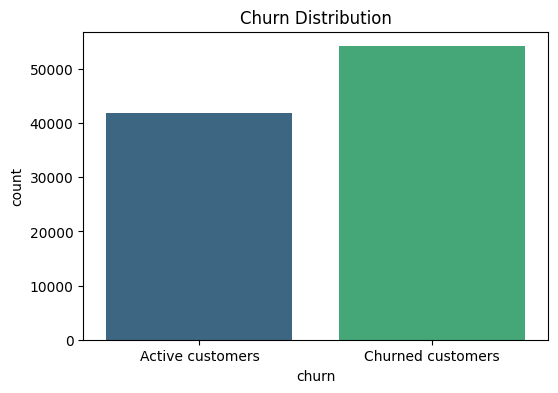

In [67]:
# Target..
print("Percentage distribution:")
print(data['churn'].value_counts(normalize=True) * 100)

# Plot distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=data, palette='viridis')
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Active customers', 'Churned customers'])  # xticks before show
plt.show()


In [68]:
# Create Lables
numerical_columns = ['total_orders', 'total_spent', 'avg_order_value',
    'avg_product_price', 'avg_review_score', 'avg_items_per_order']

categorical_columns = ['preferred_payment_type']


In [69]:
# sns.set(style="whitegrid")
# plt.figure(figsize=(18, 12))

# # Loop through each numerical column and plot its distribution
# for i, column in enumerate(numerical_columns, 1):
#     plt.subplot(2, 3, i)  # 2 rows, 3 columns layout (since we have 6 features)

#     # Calculate mean and median for the column
#     column_mean = data[column].mean()
#     column_median = data[column].median()

#     # Plot the histogram with KDE
#     sns.histplot(data[column], kde=True, bins=30, color="steelblue")

#     # Add vertical lines for mean and median
#     plt.axvline(column_mean, color="red", linestyle="--", label="Mean")
#     plt.axvline(column_median, color="green", linestyle="-", label="Median")

#     # Add title and legend
#     plt.title(f"Distribution of {column}")
#     plt.legend()

# plt.tight_layout()
# plt.show()


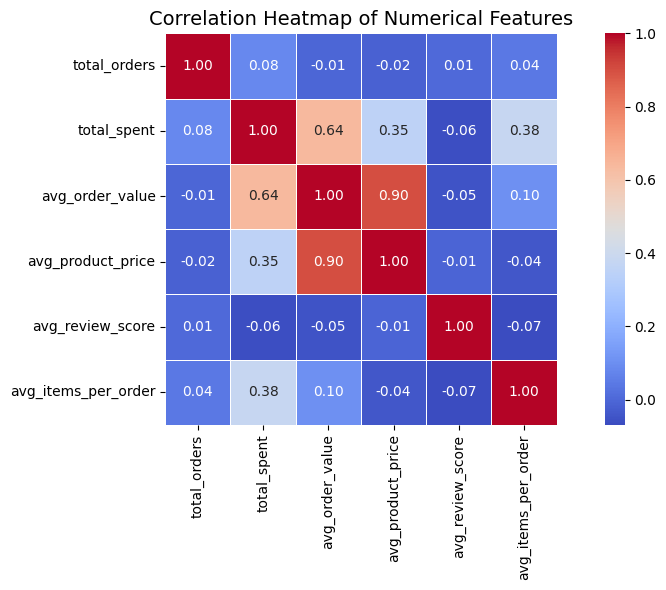

In [70]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
corr_matrix = data[numerical_columns].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5, square=True)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()


In [71]:
data['preferred_payment_type'].unique()

array(['credit_card', 'boleto', 'debit_card', 'voucher', 'not_defined'],
      dtype=object)

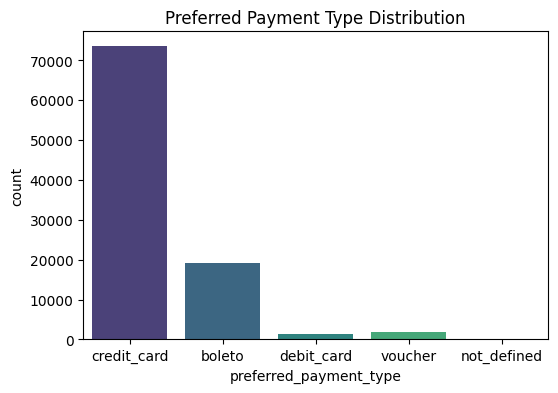

In [72]:
# Plot bar charts for categorical features
plt.figure(figsize=(6,4))
sns.countplot(x='preferred_payment_type', data=data, palette='viridis')
plt.title('Preferred Payment Type Distribution')
plt.show()


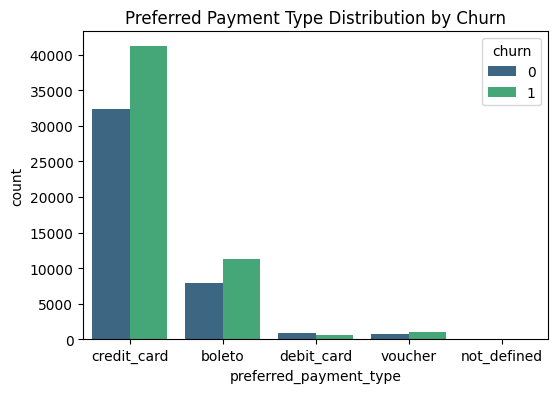

In [73]:
# Bar plots of categorical features with Churn
plt.figure(figsize=(6,4))
sns.countplot(x='preferred_payment_type', hue='churn', data=data, palette='viridis')
plt.title('Preferred Payment Type Distribution by Churn')
plt.show()


# Train-Test Split

In [74]:
# Features (X) and Target (y)
X = data.drop('churn', axis=1)
y = data['churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [75]:
# Calculate statistics for imputation
numerical_means = X[numerical_columns].mean()
numerical_medians = X[numerical_columns].median()
categorical_modes = X[categorical_columns].mode().iloc[0]

In [76]:
scaler = StandardScaler()

# Scale numerical columns
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])


In [77]:
# Initialize OneHotEncoder
oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training set and transform
encoded_train = oh_encoder.fit_transform(X_train[['preferred_payment_type']])
encoded_test = oh_encoder.transform(X_test[['preferred_payment_type']])

# Convert to DataFrames with column names
encoded_train_df = pd.DataFrame(encoded_train, columns=oh_encoder.get_feature_names_out(['preferred_payment_type']), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=oh_encoder.get_feature_names_out(['preferred_payment_type']), index=X_test.index)

# Drop original 'department' column and concatenate the one-hot encoded columns
X_train = pd.concat([X_train.drop(columns=['preferred_payment_type']), encoded_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=['preferred_payment_type']), encoded_test_df], axis=1)

In [78]:
X_train.head()

,total_orders,total_spent,avg_order_value,avg_product_price,avg_review_score,avg_items_per_order,preferred_payment_type_boleto,preferred_payment_type_credit_card,preferred_payment_type_debit_card,preferred_payment_type_not_defined,preferred_payment_type_voucher
55576,-0.160055,0.018751,0.313808,0.388500,0.688346,-0.258551,0.0,1.0,0.0,0.0,0.0
55241,4.474371,0.108124,-0.284811,-0.146852,0.189936,0.443765,0.0,1.0,0.0,0.0,0.0
76582,-0.160055,-0.186037,-0.320333,-0.266248,-0.059269,-0.258551,0.0,1.0,0.0,0.0,0.0
85195,-0.160055,-0.277785,-0.604439,-0.607054,0.688346,-0.258551,1.0,0.0,0.0,0.0,0.0
26080,-0.160055,-0.137780,-0.170902,-0.111437,0.688346,-0.258551,0.0,1.0,0.0,0.0,0.0


# Model Training & Selection

In [79]:
# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN Classifier": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier()
}

# Store mean recall scores
results = {}

print("Model Evaluation (3-Fold CV - F1 Score):\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='f1')
    mean_score = scores.mean()
    results[name] = mean_score
    print(f"{name:<30}: f1 = {mean_score:.4f}")

# Best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print("\nBest Performing Model:")
print(f"{best_model_name} with f1 score = {results[best_model_name]:.4f}")


Model Evaluation (3-Fold CV - F1 Score):

Logistic Regression           : f1 = 0.7202
KNN Classifier                : f1 = 0.6933
Decision Tree                 : f1 = 0.7467
Random Forest                 : f1 = 0.7293
Gradient Boosting             : f1 = 0.7263
AdaBoost                      : f1 = 0.7210
XGBoost                       : f1 = 0.7274

Best Performing Model:
Decision Tree with f1 score = 0.7467


# Final Evaluation


Confusion Matrix:
[[5962 2417]
 [2352 8489]]


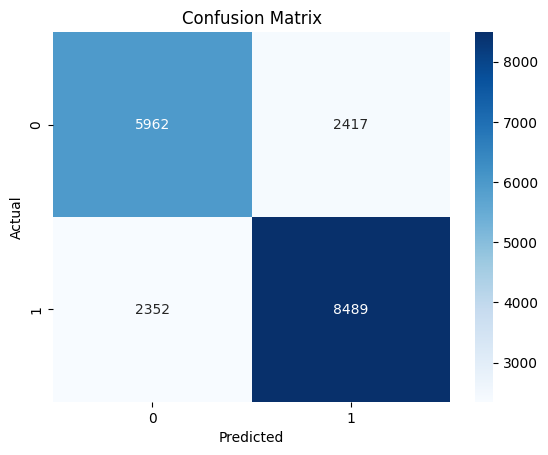


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      8379
           1       0.78      0.78      0.78     10841

    accuracy                           0.75     19220
   macro avg       0.75      0.75      0.75     19220
weighted avg       0.75      0.75      0.75     19220

Accuracy : 0.7518730489073882
Precision: 0.7783788740143041
Recall   : 0.7830458444792916
F1 Score : 0.7807053846507565


In [80]:
# Train best model on full training data
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion matrix and metrics
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Deployment Preparation

In [81]:
# Get labels for numerical and categorical columns
print("numerical_columns = ", numerical_columns)
print("categorical_columns = ", categorical_columns)

numerical_columns =  ['total_orders', 'total_spent', 'avg_order_value', 'avg_product_price', 'avg_review_score', 'avg_items_per_order']
categorical_columns =  ['preferred_payment_type']


In [82]:
# Get all column names except the target
features_columns = [col for col in raw_data.columns if col != 'churn']
print("features_columns = ", features_columns)

features_columns =  ['customer_unique_id', 'total_orders', 'total_spent', 'avg_order_value', 'preferred_payment_type', 'avg_product_price', 'avg_review_score', 'days_since_last_purchase', 'avg_items_per_order']


In [83]:
# Get dropped columns names (if any were removed during preprocessing)
dropped_columns = list(set(raw_data.columns) - set(X.columns) - set(['churn']))
print("dropped_columns = ", dropped_columns)

dropped_columns =  ['customer_unique_id', 'days_since_last_purchase']


In [84]:
# Example: Enter new input customer data (format must match features_columns order)
input_data = "C123,5,1200,240,credit_card,60,4.5,30,2"

# Split the input string by commas
values = input_data.split(',')

# Function to check if a value is numeric
def enclose_value(value):
    # Handle missing values
    if value == '' or value is None:
        return np.nan
    try:
        if '.' in value:
            return float(value)
        else:
            return int(value)
    except ValueError:
        return value

# Convert all values properly
processed_values = [enclose_value(v) for v in values]

# Validate input length
if len(processed_values) != len(features_columns):
    raise ValueError("Input data does not match the expected number of features.")

# Convert the processed values into a DataFrame
input_data = pd.DataFrame([processed_values], columns=features_columns)

# Remove dropped columns
if dropped_columns:
    input_df = input_data.drop(columns=dropped_columns, errors='ignore')

# Handle Missing Values
input_df[numerical_columns] = input_df[numerical_columns].fillna(numerical_means)
input_df[categorical_columns] = input_df[categorical_columns].fillna(categorical_modes)

# Scale numerical columns
input_df[numerical_columns] = scaler.transform(input_df[numerical_columns])

# Encode categorical column (preferred_payment_type)
payment_encoded = oh_encoder.transform(input_df[['preferred_payment_type']])
payment_encoded_df = pd.DataFrame(payment_encoded,
                                  columns=oh_encoder.get_feature_names_out(['preferred_payment_type']),
                                  index=input_df.index)

# Drop original categorical column and merge encoded ones
input_df = input_df.drop(columns=['preferred_payment_type'])
input_df = pd.concat([input_df, payment_encoded_df], axis=1)

# Ensure same column order as training
input_df = input_df.reindex(columns=X_train.columns, fill_value=0)

# Predict
prediction = best_model.predict(input_df)[0]
print("Prediction Result:", "Customer will Churn" if prediction == 1 else "Customer will Stay")


Prediction Result: Customer will Stay


# Saved Artifacts

In [85]:
# Save the best model
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the OneHot encoder
with open('oh_encoder.pkl', 'wb') as f:
    pickle.dump(oh_encoder, f)

# Save the statistical values for imputation
with open('numerical_means.pkl', 'wb') as f:
    pickle.dump(numerical_means, f)
with open('numerical_medians.pkl', 'wb') as f:
    pickle.dump(numerical_medians, f)
with open('categorical_modes.pkl', 'wb') as f:
    pickle.dump(categorical_modes, f)

# Print success message
print("Model, scaler, encoder, and statistical values saved successfully!")


Model, scaler, encoder, and statistical values saved successfully!


# Deployment Script (predict_churn.py)

In [86]:
code = '''
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Load the trained model and preprocessing objects
with open("churn_model.pkl", "rb") as f:
    churn_model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("oh_encoder.pkl", "rb") as f:
    oh_encoder = pickle.load(f)

with open("numerical_means.pkl", "rb") as f:
    numerical_means = pickle.load(f)

with open("numerical_medians.pkl", "rb") as f:
    numerical_medians = pickle.load(f)

with open("categorical_modes.pkl", "rb") as f:
    categorical_modes = pickle.load(f)

print("Model, encoder, scaler, and statistics loaded successfully!\\n")

# Define column lists
numerical_columns = ['total_orders', 'total_spent', 'avg_order_value',
                     'avg_product_price', 'avg_review_score', 'avg_items_per_order']

categorical_columns = ['preferred_payment_type']

features_columns = ['customer_unique_id', 'total_orders', 'total_spent', 'avg_order_value',
                    'preferred_payment_type', 'avg_product_price', 'avg_review_score',
                    'days_since_last_purchase', 'avg_items_per_order']

dropped_columns = ['customer_unique_id', 'days_since_last_purchase']

# Example new input data
# Format: customer_unique_id,total_orders,total_spent,avg_order_value,preferred_payment_type,avg_product_price,avg_review_score,days_since_last_purchase,avg_items_per_order
input_data = "CUST001,10,500,50,credit_card,45,4.2,30,2"

# Split the input string by commas
values = input_data.split(',')

# Convert to proper types
def enclose_value(value):
    if value == "" or value is None:
        return np.nan
    try:
        if "." in value:
            return float(value)
        else:
            return int(value)
    except ValueError:
        return value

processed_values = [enclose_value(v) for v in values]

# Validate input length
if len(processed_values) != len(features_columns):
    raise ValueError("Input data does not match the expected number of features.")

# Convert the processed values into a DataFrame
input_data = pd.DataFrame([processed_values], columns=features_columns)

# Remove dropped columns
if dropped_columns:
    input_df = input_data.drop(columns=dropped_columns, errors='ignore')

# Handle missing values
input_df[numerical_columns] = input_df[numerical_columns].fillna(numerical_means)
input_df[categorical_columns] = input_df[categorical_columns].fillna(categorical_modes)

# Scale numerical columns
input_df[numerical_columns] = scaler.transform(input_df[numerical_columns])

# Encode preferred_payment_type (OneHot)
pay_encoded = oh_encoder.transform(input_df[['preferred_payment_type']])
pay_encoded_df = pd.DataFrame(pay_encoded, columns=oh_encoder.get_feature_names_out(['preferred_payment_type']), index=input_df.index)

# Drop original categorical column and merge encoded ones
input_df = input_df.drop(columns=['preferred_payment_type'])
input_df = pd.concat([input_df, pay_encoded_df], axis=1)

# Make prediction
prediction = churn_model.predict(input_df)[0]
print("Prediction Result:", "Customer will Churn" if prediction == 1 else "Customer will Stay")
'''

# Define the filename to save the deployment script
filename = "predict_churn.py"

with open(filename, "w") as file:
    file.write(code)

print("Deployment script saved as predict_churn.py")


Deployment script saved as predict_churn.py
